In [1]:
import numpy as np
import os
import glob
import json
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import levene
from itertools import combinations
import sys
sys.path.append('../../..')
from style_setup import set_thesis_style
set_thesis_style()

# Analysis code

In [63]:
# ==============================================================================
# HELPER & CORE FUNCTIONS
# ==============================================================================

def _print_header(title):
    """Helper to print a standardized header."""
    print("\n" + "=" * 70)
    print(title.center(70))
    print("=" * 70)

def load_perplexity_data(data_path, datasets_config):
    """Loads perplexity scores from .jsonl files."""
    if not os.path.isdir(data_path):
        print(f"Error: Data directory not found at '{data_path}'")
        return None
        
    perplexities_by_dataset = {}
    filename_to_dataset_name = {filename: name for name, filename in datasets_config}
    
    for file_path in glob.glob(os.path.join(data_path, "ppl*.jsonl")):
        file_name = os.path.basename(file_path)
        if file_name in filename_to_dataset_name:
            dataset_name = filename_to_dataset_name[file_name]
            perplexities = []
            with open(file_path, 'r') as f:
                for line in f:
                    try:
                        data = json.loads(line)
                        perplexity = data.get("token_probabilities", {}).get("perplexity")
                        if perplexity is not None and np.isfinite(perplexity):
                            perplexities.append(perplexity)
                    except json.JSONDecodeError:
                        print(f"Warning: Could not decode JSON from a line in {file_name}")
            perplexities_by_dataset[dataset_name] = perplexities
            
    ordered_perplexities = {
        name: perplexities_by_dataset.get(name, []) 
        for name, _ in datasets_config 
        if name in perplexities_by_dataset
    }
    return ordered_perplexities

def remove_outliers_iqr(perplexities_by_dataset, factor=1.5):
    """Removes outliers using the Interquartile Range (IQR) method."""
    cleaned_data = {}
    _print_header("Outlier Removal using IQR method")
    print(f"Factor: {factor}\n")
    for name, data in perplexities_by_dataset.items():
        if not data:
            cleaned_data[name] = []
            continue
            
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower_bound = q1 - (factor * iqr)
        upper_bound = q3 + (factor * iqr)
        
        original_count = len(data)
        filtered_data = [x for x in data if lower_bound <= x <= upper_bound]
        cleaned_data[name] = filtered_data
        
        print(f"Dataset: {name}")
        print(f"  Original Count: {original_count}")
        print(f"  Removed: {original_count - len(filtered_data)}")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  New Count: {len(filtered_data)}\n")
        
    return cleaned_data

def calculate_statistics(perplexities_by_dataset):
    """Calculates descriptive statistics for perplexity scores."""
    stats_data = []
    for name, values in perplexities_by_dataset.items():
        if values:
            stats_data.append({
                "Dataset": name,
                "Count": len(values),
                "Mean": np.mean(values),
                "Median": np.median(values),
                "Variance": np.var(values, ddof=1),
                "Std. Dev.": np.std(values, ddof=1),
            })
    return pd.DataFrame(stats_data).set_index("Dataset")

def plot_perplexity_distributions(perplexities, stats_df, data_size, suffix="", output_path=None):
    """Generates and saves a boxplot of perplexity distributions."""
    #plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 10))
    plot_data = pd.DataFrame([
        {'Dataset': name, 'Perplexity': score}
        for name, scores in perplexities.items() for score in scores
    ])
    ax = sns.boxplot(data=plot_data, x='Dataset', y='Perplexity', hue='Dataset',
                      order=perplexities.keys())
    means = stats_df["Mean"]
    for i, name in enumerate(perplexities.keys()):
        if name in means:
            plt.plot(i, means[name], 'o', color='red', markersize=10, 
                     markeredgecolor='black', label='Mean' if i == 0 else "")
    ax.set_xlabel('Finetuning Dataset', fontsize=18, labelpad=15)
    ax.set_ylabel('Perplexity (Log Scale)', fontsize=18, labelpad=15)
    ax.set_title(f'Perplexity of Llama-{data_size.capitalize()} on Generated Outputs{suffix}', fontsize=22, pad=20)
    ax.set_yscale('log')
    ax.tick_params(axis='x', labelsize=16); ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3, axis='both')
    handles, labels = ax.get_legend_handles_labels()
    if 'Mean' in labels:
        ax.legend(handles=[handles[labels.index('Mean')]], labels=['Mean'], fontsize=16, frameon=True)
    else:
        ax.legend().remove()
    plt.tight_layout()
    if output_path:
        filename = f"box_ppl_dist_{data_size}{'_cleaned' if suffix else ''}.png"
        plt.savefig(os.path.join(output_path, filename), dpi=300)
        print(f"\nPlot saved to {os.path.join(output_path, filename)}")
    else:
        plt.show()

def plot_perplexity_distributions_no_human(perplexities, stats_df, data_size, suffix="", output_path=None):
    """Generates and saves a boxplot of perplexity distributions, excluding human-source data."""
    #plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 10))
    
    # Filter out human-source data
    filtered_perplexities = {name: scores for name, scores in perplexities.items() 
                           if 'human' not in name.lower()}
    
    plot_data = pd.DataFrame([
        {'Dataset': name, 'Perplexity': score}
        for name, scores in filtered_perplexities.items() for score in scores
    ])
    ax = sns.boxplot(data=plot_data, x='Dataset', y='Perplexity', hue='Dataset',
                      order=filtered_perplexities.keys())
    means = stats_df["Mean"]
    for i, name in enumerate(filtered_perplexities.keys()):
        if name in means:
            plt.plot(i, means[name], 'o', color='red', markersize=10, 
                     markeredgecolor='black', label='Mean' if i == 0 else "")
    ax.set_xlabel('Finetuning Dataset', fontsize=18, labelpad=15)
    ax.set_ylabel('Perplexity (Log Scale)', fontsize=18, labelpad=15)
    ax.set_title(f'Perplexity of Llama-{data_size.capitalize()} on Generated Outputs{suffix}', fontsize=22, pad=20)
    ax.set_yscale('log')
    ax.tick_params(axis='x', labelsize=16); ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3, axis='both')
    handles, labels = ax.get_legend_handles_labels()
    if 'Mean' in labels:
        ax.legend(handles=[handles[labels.index('Mean')]], labels=['Mean'], fontsize=16, frameon=True)
    else:
        ax.legend().remove()
    plt.tight_layout()
    if output_path:
        filename = f"box_ppl_dist_{data_size}_no_human{'_cleaned' if suffix else ''}.png"
        plt.savefig(os.path.join(output_path, filename), dpi=300)
        print(f"\nPlot saved to {os.path.join(output_path, filename)}")
    else:
        plt.show()

def plot_perplexity_histograms(perplexities, stats_df, data_size, suffix="", output_path=None, xlim=None, ylim=None, bin_width=None):
    """
    Generates and saves separate histogram plots for each dataset, skipping 'Human-Source'.
    Uses a specific color palette for the histogram bars.
    Can specify bin_width to control histogram binning.
    """
    # Colors from style_setup.py
    colors = [
        "#4C72B0",  # blue
        "#55A868",  # green
        "#C44E52",  # red
    ]

    # Filter out 'Human-Source' before plotting
    datasets_to_plot = {name: values for name, values in perplexities.items() if name != 'Human-Source'}

    for i, (name, values) in enumerate(datasets_to_plot.items()):
        # Create individual figure for each dataset
        plt.figure(figsize=(10, 6))
        
        # Assign color from the palette based on the plot index
        bar_color = colors[i % len(colors)]
        
        # Determine the bins for the histogram
        if bin_width:
            # Calculate bin edges based on the specified width
            min_val = np.min(values)
            max_val = np.max(values)
            bins = np.arange(min_val, max_val + bin_width, bin_width)
        else:
            # Default to a fixed number of bins if width is not provided
            bins = 30

        # Create histogram with density=True to show proportions
        plt.hist(values, bins=bins, alpha=0.7, edgecolor='black', linewidth=0.5, density=True, color=bar_color)
        
        # Add mean line
        if name in stats_df.index:
            mean_val = stats_df.loc[name, "Mean"]
            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {mean_val:.2f}')
        
        # Add median line
        if name in stats_df.index:
            median_val = stats_df.loc[name, "Median"]
            plt.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                       label=f'Median: {median_val:.2f}')
        
        plt.xlabel('Perplexity', fontsize=14)
        plt.ylabel('Proportion', fontsize=14)
        plt.title(f'Perplexity Distribution: {name}', fontsize=16, fontweight='bold')
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        if xlim:
            plt.xlim(xlim)

        if ylim:
            plt.ylim(ylim)
        
        # Use log scale for x-axis if perplexities are very large
        if max(values) > 1000:
            plt.xscale('log')
        
        plt.tight_layout()
        
        if output_path:
            # Create filename with dataset name
            safe_name = name.replace(' ', '_').replace('/', '_')
            filename = f"hist_ppl_{safe_name}_{data_size}.png"
            plt.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')
            print(f"Histogram plot for {name} saved to {os.path.join(output_path, filename)}")
        else:
            plt.show()
        
        plt.close()  # Close the figure to free memory


def _print_pairwise_results(pairs, results, alpha, test_name):
    """Helper to print pairwise test results in a structured table."""
    bonferroni_alpha = alpha / len(pairs)
    print(f"\nPairwise {test_name} with Bonferroni correction (alpha = {bonferroni_alpha:.2e})")
    results_df = pd.DataFrame(results, columns=['Group 1', 'Group 2', 'Statistic', 'p-value'])
    results_df['Significant'] = results_df['p-value'] < bonferroni_alpha
    results_df['p-value'] = results_df['p-value'].map('{:.2e}'.format)
    results_df['Statistic'] = results_df['Statistic'].map('{:.2f}'.format)
    print(results_df.to_string(index=False))

def run_statistical_test(test_func, perplexities, alpha, title, test_name):
    """A generic runner for overall and pairwise statistical tests."""
    _print_header(title)
    groups = list(perplexities.values())
    group_names = list(perplexities.keys())
    if len(groups) < 2:
        print("Need at least two groups to run tests.")
        return
    stat, p_value = test_func(*groups)
    print(f"Overall Test on groups: {', '.join(group_names)}")
    print(f"Statistic: {stat:.4f}, p-value: {p_value:.3e}")
    is_significant = p_value < alpha
    print(f"Result: The test is {'significant' if is_significant else 'not significant'} at alpha={alpha}.")
    if is_significant:
        pairs = list(combinations(group_names, 2))
        pairwise_results = [
            (g1, g2, *test_func(perplexities[g1], perplexities[g2]))
            for g1, g2 in pairs
        ]
        _print_pairwise_results(pairs, pairwise_results, alpha, test_name)


# Small models

Loading data for 'small' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/perplexity

                  Descriptive Statistics (Raw Data)                   
                Count         Mean    Median      Variance      Std. Dev.
Dataset                                                                  
Single-Source    1502     1.286469  1.254865  3.136981e-02       0.177115
Multi-Source     1502     1.458623  1.353935  1.702328e-01       0.412593
Human-Source     1502  3766.977717  2.500460  1.221978e+10  110543.132722
None (Vanilla)   1502     1.380878  1.284695  1.687208e-01       0.410756

                   Outlier Removal using IQR method                   
Factor: 1.5

Dataset: Single-Source
  Original Count: 1502
  Removed: 61
  Bounds: [0.90, 1.62]
  New Count: 1441

Dataset: Multi-Source
  Original Count: 1502
  Removed: 104
  Bounds: [0.80, 1.98]
  New Count: 1398

Dataset: Human-Source
  Original Count: 1502
  Removed: 148
  Bounds: [-1.90, 7.58]
  New Co

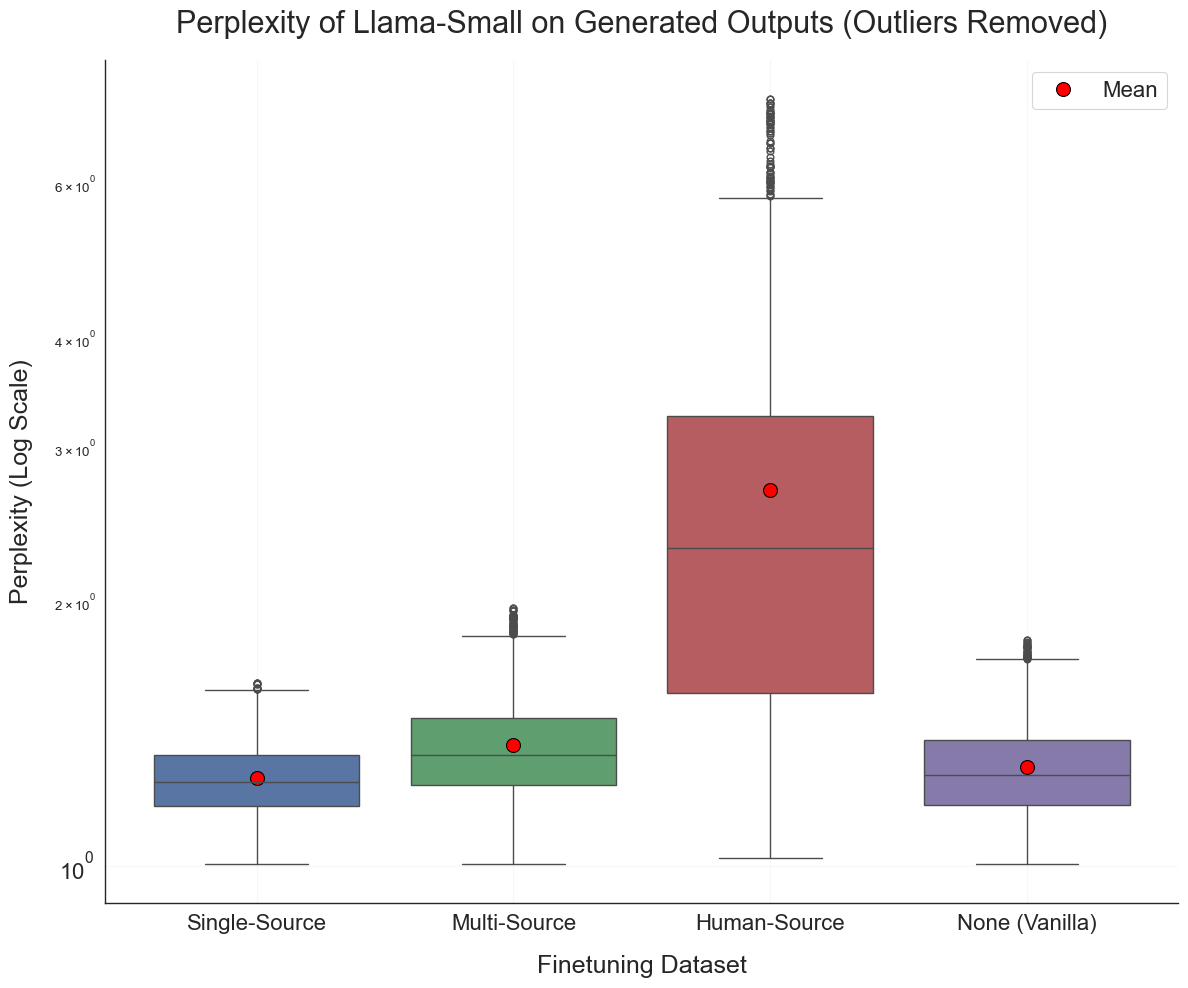

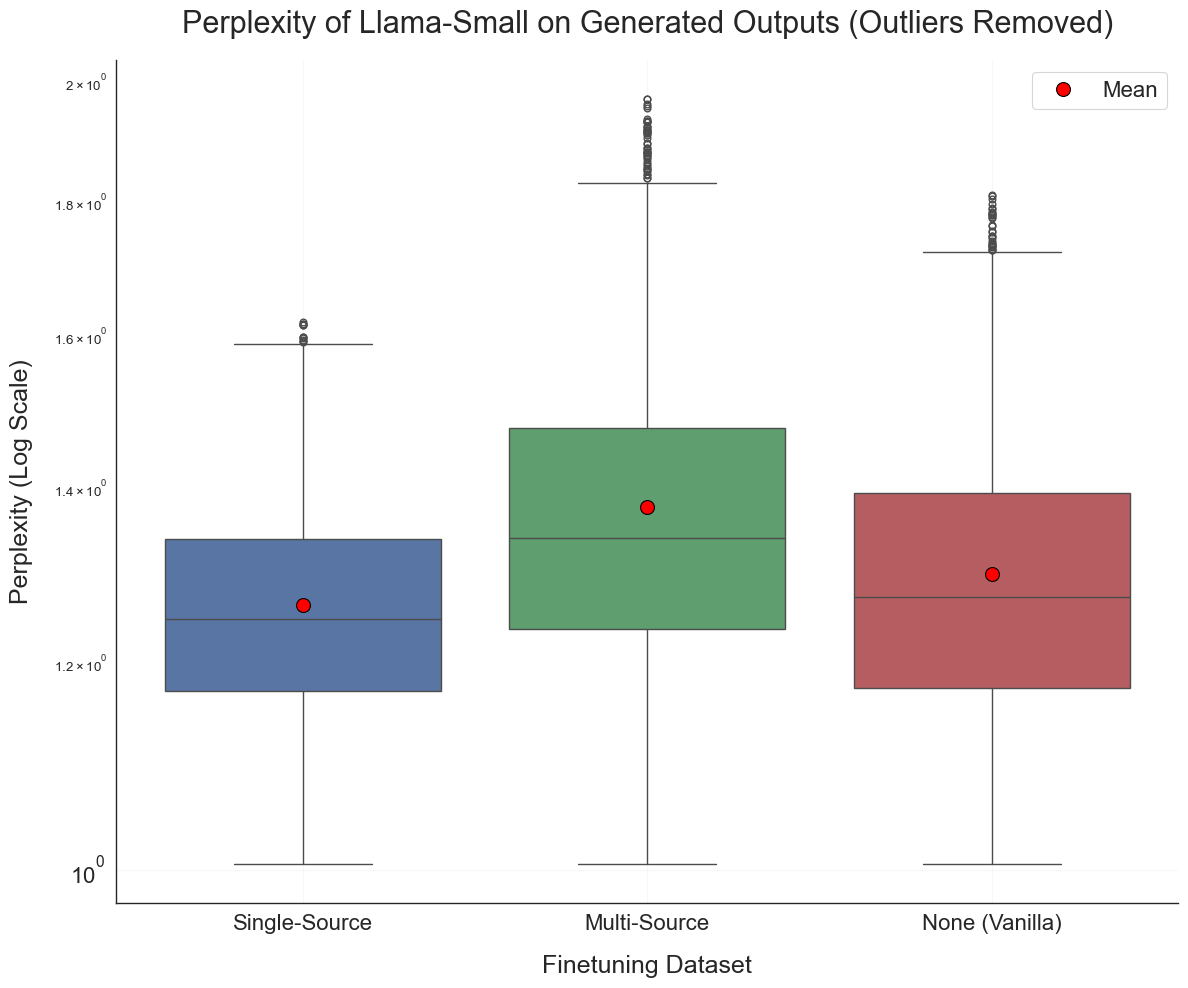

Histogram plot for Single-Source saved to /Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/hist_ppl_Single-Source_small.png
Histogram plot for Multi-Source saved to /Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/hist_ppl_Multi-Source_small.png
Histogram plot for None (Vanilla) saved to /Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/hist_ppl_None_(Vanilla)_small.png

               Homogeneity of Variance (Levene's Test)                
Overall Test on groups: Single-Source, Multi-Source, Human-Source, None (Vanilla)
Statistic: 1145.4543, p-value: 0.000e+00
Result: The test is significant at alpha=0.05.

Pairwise Levene's with Bonferroni correction (alpha = 8.33e-03)
      Group 1        Group 2 Statistic   p-value  Significant
Single-Source   Multi-Source    163.74  1.73e-36         True
Single-Source   Human-Source   1272.73 5.09e-230         True
Single-Source None (Vanilla)     73.96  1.30e-17         True
 Multi-Source   Human-Source   1092.43 5.05e-202         True

In [66]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "small"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = True
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source", "ppl_lora_llama_8b_single.jsonl"),
    ("Multi-Source", "ppl_lora_llama_8b_multi.jsonl"),
    ("Human-Source", "ppl_lora_llama_8b_human.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_8b.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None)
    plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None)
    plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH, xlim=(0.8, 2.2), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    levene_test_func = lambda *args: stats.levene(*args, center='median')
    run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")

In [40]:
import json
import os
import random
from pathlib import Path

# Path to outputs directory
outputs_path = Path("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/outputs")

# Function to extract and display example responses
def show_example_responses():
    print("=" * 80)
    print("EXAMPLE RESPONSES FROM OUTPUT FILES")
    print("=" * 80)
    
    # Get all JSONL files in outputs directory
    jsonl_files = list(outputs_path.glob("*.jsonl"))
    
    if not jsonl_files:
        print("No JSONL files found in outputs directory")
        return
    
    for file_path in jsonl_files:
        print(f"\n📁 File: {file_path.name}")
        print("-" * 60)
        
        try:
            # Read JSONL file line by line
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
            
            if not lines:
                print("❌ Empty file")
                continue
            
            # Parse all lines and extract responses and instructions
            all_responses = []
            all_instructions = []
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                    
                try:
                    data = json.loads(line)
                    if "response_model" in data:
                        all_responses.append(data["response_model"])
                    if "instruction" in data:
                        all_instructions.append(data["instruction"])
                except json.JSONDecodeError:
                    continue
            
            if not all_responses:
                print("❌ No valid responses found in this file")
                continue
            
            # Sample 30 responses randomly (or all if less than 30)
            sample_size = min(30, len(all_responses))
            sampled_indices = random.sample(range(len(all_responses)), sample_size)
            sampled_responses = [all_responses[i] for i in sampled_indices]
            sampled_instructions = [all_instructions[i] if i < len(all_instructions) else "No instruction found" for i in sampled_indices]
            
            print(f"Showing {sample_size} randomly sampled responses (out of {len(all_responses)} total):")
            print()
            
            for i, (response, instruction) in enumerate(zip(sampled_responses, sampled_instructions), 1):
                print(f"Response {i}:")
                print(f"Type: {type(response)}")
                print(f"Instruction: {instruction}")
                
                # Handle different response formats
                if isinstance(response, str):
                    # Truncate long responses for display
                    display_text = response[:500] + "..." if len(response) > 500 else response
                    print(f"Content: {display_text}")
                elif isinstance(response, dict):
                    print(f"Content: {json.dumps(response, indent=2, ensure_ascii=False)[:500]}...")
                elif isinstance(response, list):
                    print(f"Content: {str(response)[:500]}...")
                else:
                    print(f"Content: {str(response)[:500]}...")
                print("-" * 40)
                
        except Exception as e:
            print(f"❌ Error reading file: {e}")
        
        print()

# Execute the function
show_example_responses()


EXAMPLE RESPONSES FROM OUTPUT FILES

📁 File: output_lora_llama_8b_human.jsonl
------------------------------------------------------------
Showing 30 randomly sampled responses (out of 1502 total):

Response 1:
Type: <class 'str'>
Instruction: What are some weight loss tips?
Content: - Eat more plant-based foods, such as fruits, vegetables, whole grains, and legumes. These foods are generally low in calories and high in fiber, which can help you feel full and satisfied.
- Incorporate healthy fats into your diet, such as nuts, seeds, avocados, and olive oil. These fats can help you feel full and satisfied, and can also provide essential nutrients.
- Drink plenty of water. Aim to drink at least eight glasses of water per day.
- Exercise regularly. Aim for at least 30 minutes o...
----------------------------------------
Response 2:
Type: <class 'str'>
Instruction: Tell me whether these are movies or books: Jurassic, Harry Potter and the Philosopher's Stone, Angels and Demons
Content: Jur

# Medium models

## Same size finetuning datasets

Loading data for 'medium' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity

                  Descriptive Statistics (Raw Data)                   
                Count         Mean    Median      Variance     Std. Dev.
Dataset                                                                 
Single-Source    1502     1.227656  1.145345  6.139376e-01      0.783542
Multi-Source     1502     2.480096  1.247780  1.802197e+03     42.452293
Human-Source     1502  1799.977346  2.243555  2.634596e+09  51328.319499
None (Vanilla)   1502     1.227870  1.201350  2.116982e-02      0.145499

                   Outlier Removal using IQR method                   
Factor: 1.5

Dataset: Single-Source
  Original Count: 1502
  Removed: 90
  Bounds: [0.94, 1.36]
  New Count: 1412

Dataset: Multi-Source
  Original Count: 1502
  Removed: 88
  Bounds: [0.84, 1.69]
  New Count: 1414

Dataset: Human-Source
  Original Count: 1502
  Removed: 137
  Bounds: [-1.28, 6.27]
  New Count: 

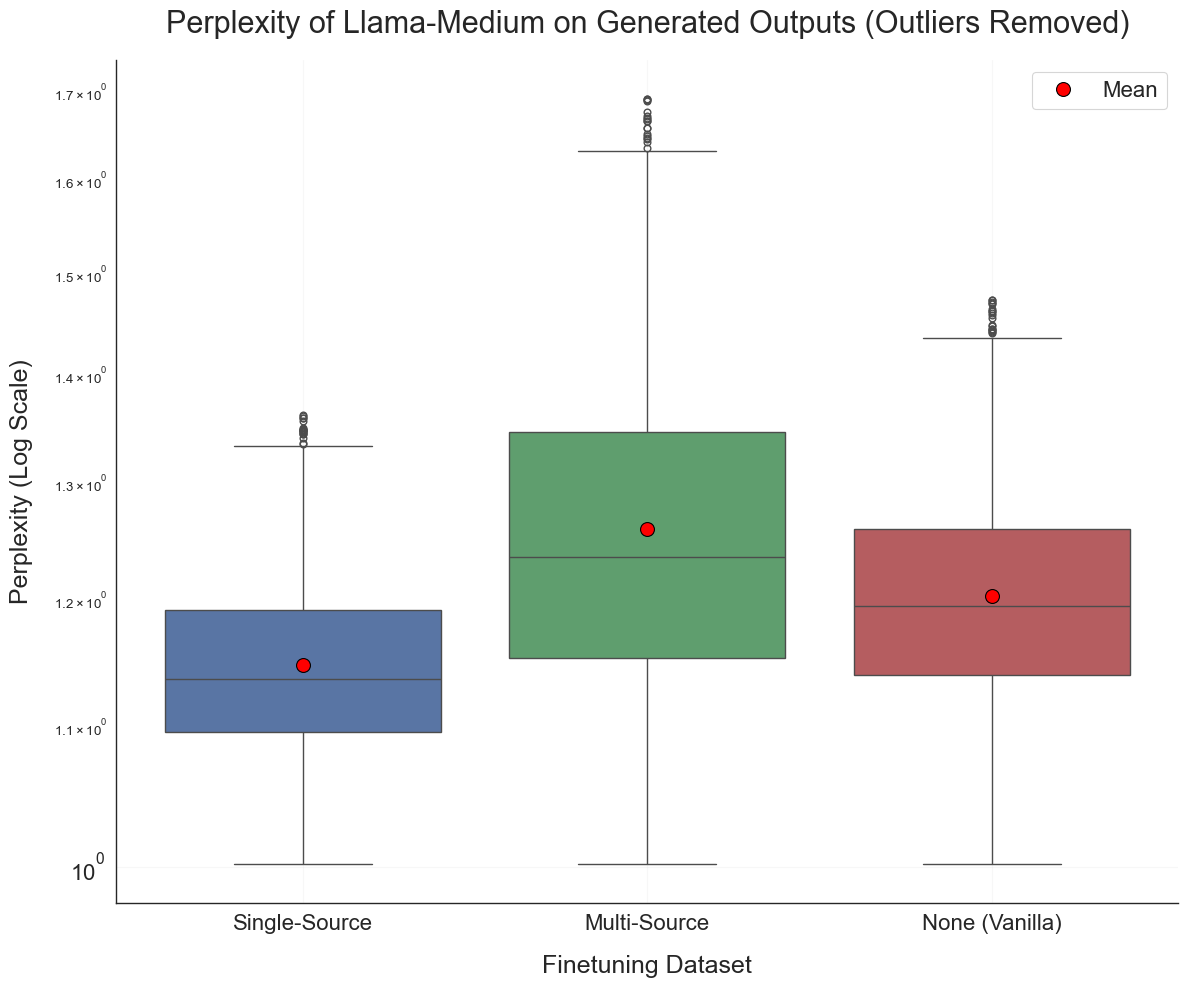

Histogram plot for Single-Source saved to /Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/hist_ppl_Single-Source_medium.png
Histogram plot for Multi-Source saved to /Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/hist_ppl_Multi-Source_medium.png
Histogram plot for None (Vanilla) saved to /Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/hist_ppl_None_(Vanilla)_medium.png

               Homogeneity of Variance (Levene's Test)                
Overall Test on groups: Single-Source, Multi-Source, Human-Source, None (Vanilla)
Statistic: 1408.4430, p-value: 0.000e+00
Result: The test is significant at alpha=0.05.

Pairwise Levene's with Bonferroni correction (alpha = 8.33e-03)
      Group 1        Group 2 Statistic   p-value  Significant
Single-Source   Multi-Source    401.92  1.07e-83         True
Single-Source   Human-Source   1510.69 3.20e-264         True
Single-Source None (Vanilla)     59.42  1.75e-14         True
 Multi-Source   Human-Source   1305.35 1.21e-234         T

In [68]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "medium"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = True
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source", "ppl_lora_llama_70b_single_medium.jsonl"),
    ("Multi-Source", "ppl_lora_llama_70b_multi_medium.jsonl"),
    ("Human-Source", "ppl_lora_llama_70b_human.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_70b.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None)
    plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH, xlim=(0.8, 1.8), ylim=(0, 6.5), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    levene_test_func = lambda *args: stats.levene(*args, center='median')
    run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")

## Different size finetuning datasets

### Single-source

Loading data for 'medium' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity

                  Descriptive Statistics (Raw Data)                   
                      Count      Mean    Median  Variance  Std. Dev.
Dataset                                                             
Single-Source Small    1502  1.353900  1.264475  0.618788   0.786630
Single-Source Medium   1502  1.227656  1.145345  0.613938   0.783542
Single-Source Large    1502  1.251893  1.170225  0.611069   0.781709

                   Outlier Removal using IQR method                   
Factor: 1.5

Dataset: Single-Source Small
  Original Count: 1502
  Removed: 80
  Bounds: [0.89, 1.66]
  New Count: 1422

Dataset: Single-Source Medium
  Original Count: 1502
  Removed: 90
  Bounds: [0.94, 1.36]
  New Count: 1412

Dataset: Single-Source Large
  Original Count: 1502
  Removed: 77
  Bounds: [0.92, 1.44]
  New Count: 1425


                Descriptive Statistics (Cleaned Data)              

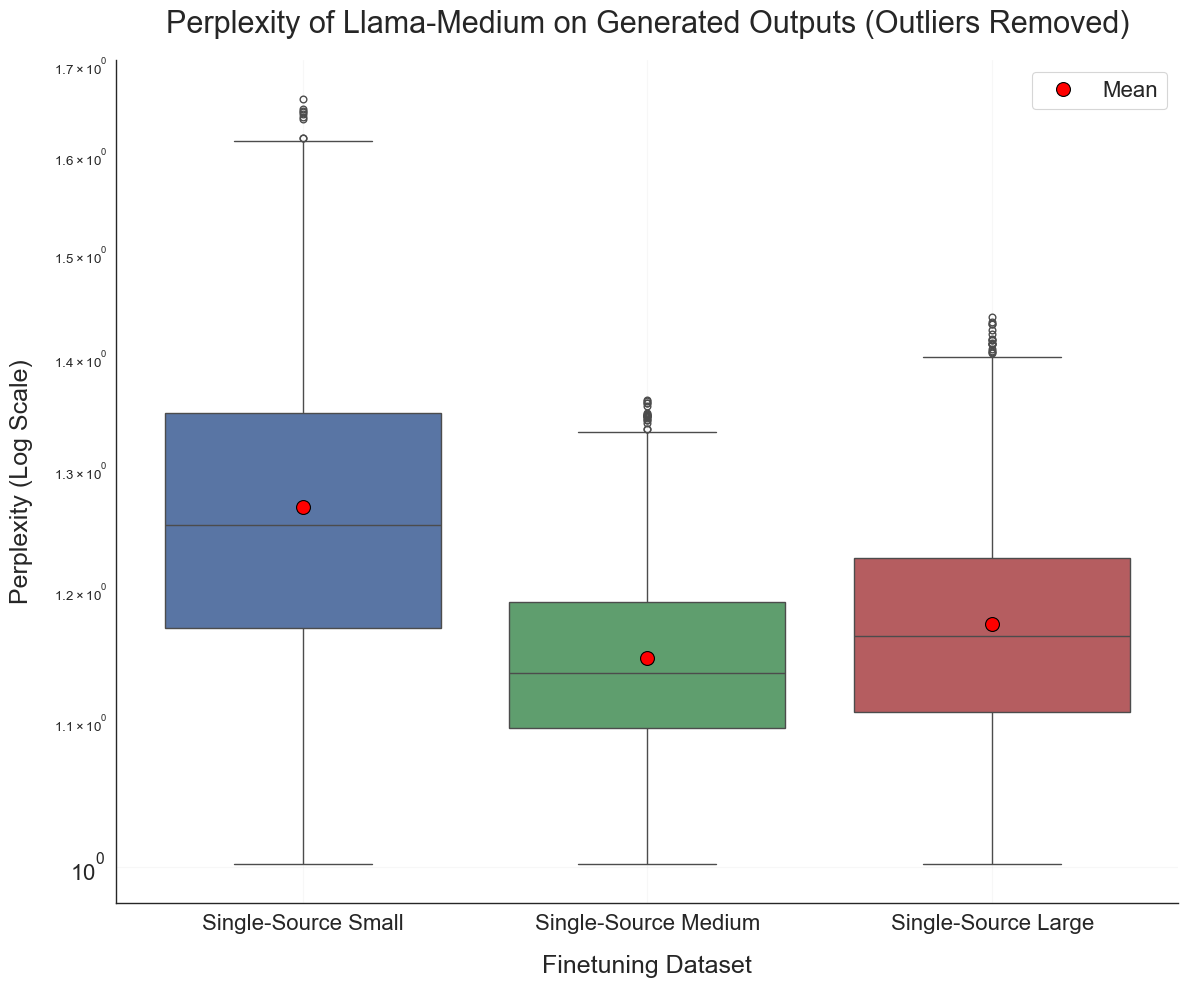

In [71]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "medium"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = True
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source Small", "ppl_lora_llama_70b_single_small.jsonl"),
    ("Single-Source Medium", "ppl_lora_llama_70b_single_medium.jsonl"),
    ("Single-Source Large", "ppl_lora_llama_70b_single_large.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH, xlim=(0.8, 1.8), ylim=(0, 6.5), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    levene_test_func = lambda *args: stats.levene(*args, center='median')
    run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")

### Multi-source

Loading data for 'medium' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity

                  Descriptive Statistics (Raw Data)                   
                     Count      Mean    Median     Variance  Std. Dev.
Dataset                                                               
Multi-Source Small    1502  1.539557  1.358615     0.859703   0.927202
Multi-Source Medium   1502  2.480096  1.247780  1802.197152  42.452293
Multi-Source Large    1502  1.541715  1.422140     0.721399   0.849352

                   Outlier Removal using IQR method                   
Factor: 1.5

Dataset: Multi-Source Small
  Original Count: 1502
  Removed: 104
  Bounds: [0.74, 2.06]
  New Count: 1398

Dataset: Multi-Source Medium
  Original Count: 1502
  Removed: 88
  Bounds: [0.84, 1.69]
  New Count: 1414

Dataset: Multi-Source Large
  Original Count: 1502
  Removed: 74
  Bounds: [0.75, 2.12]
  New Count: 1428


                Descriptive Statistics (Cleaned Data)      

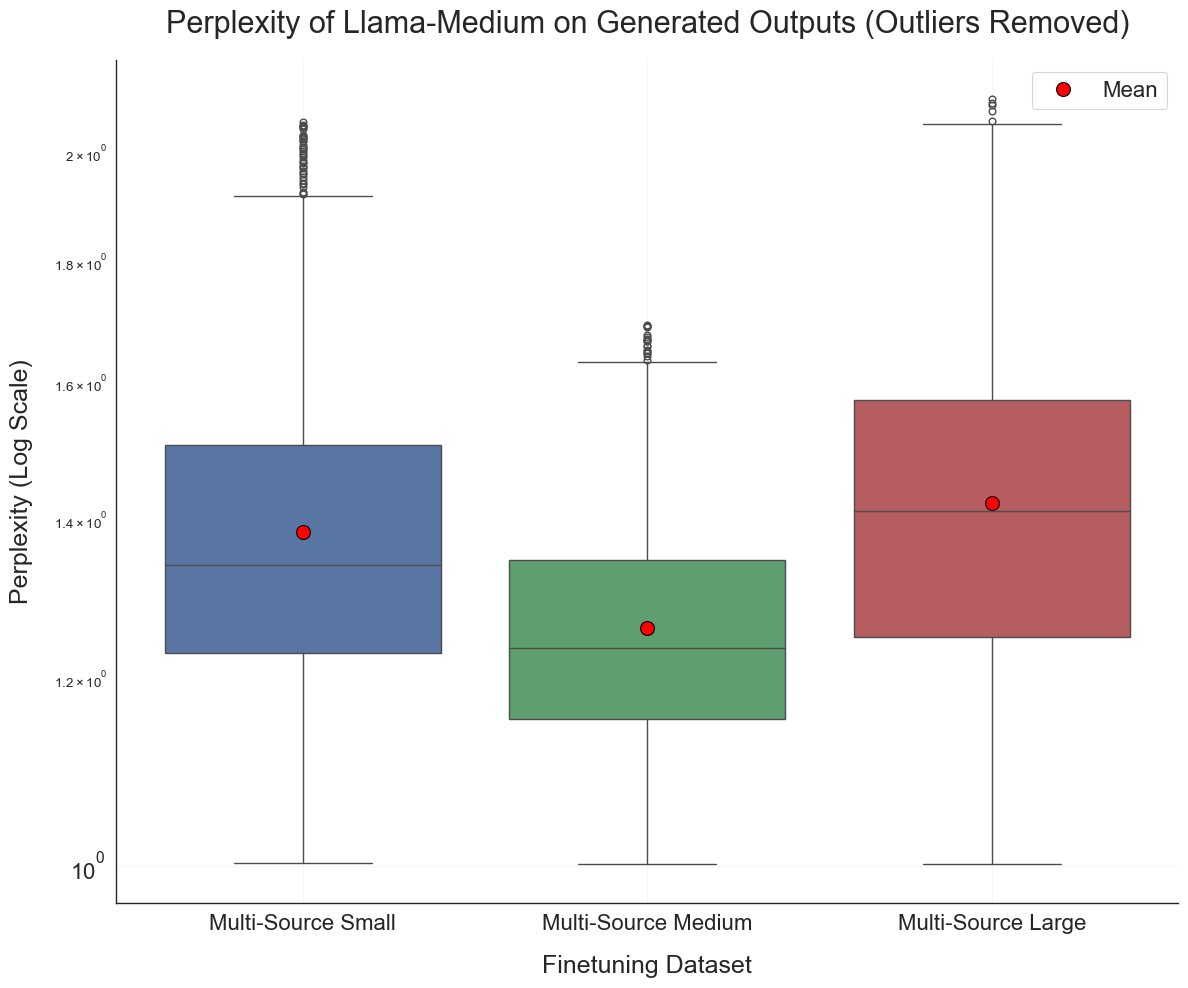

In [75]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "medium"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = True
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Multi-Source Small", "ppl_lora_llama_70b_multi_small.jsonl"),
    ("Multi-Source Medium", "ppl_lora_llama_70b_multi_medium.jsonl"),
    ("Multi-Source Large", "ppl_lora_llama_70b_multi_large.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH, xlim=(0.8, 2.2), ylim=(0, 3.5), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    levene_test_func = lambda *args: stats.levene(*args, center='median')
    run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")